Saving computers.csv to computers (4).csv


,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74


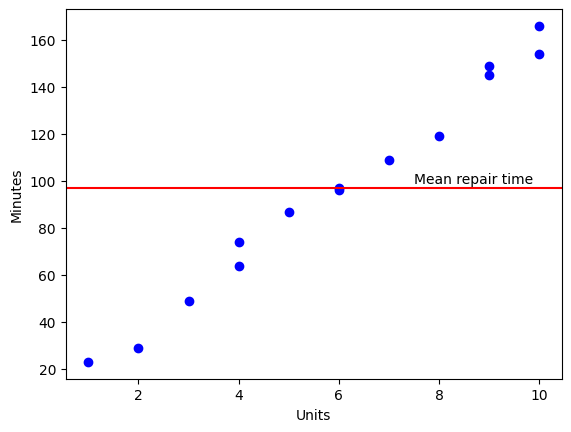

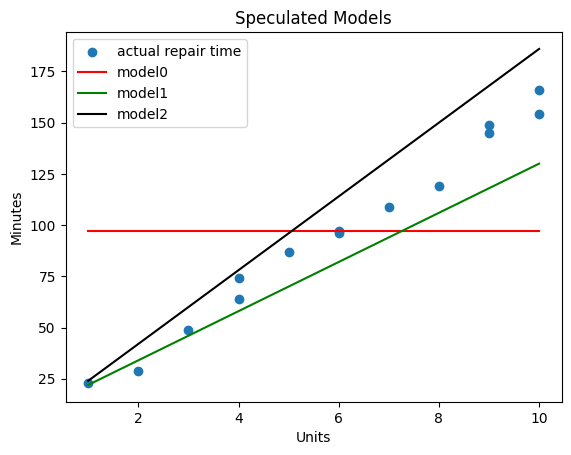

,Units,Actual time,Predicted time,Error
0,1,23,97.214286,74.214286
1,2,29,97.214286,68.214286
2,3,49,97.214286,48.214286
3,4,64,97.214286,33.214286
4,4,74,97.214286,23.214286
5,5,87,97.214286,10.214286
6,6,96,97.214286,1.214286
7,6,97,97.214286,0.214286
8,7,109,97.214286,-11.785714
9,8,119,97.214286,-21.785714


'SSE for model0 is:'

27768.35714285714

,Units,Actual time,Predicted time,Error
0,1,23,22,-1
1,2,29,34,5
2,3,49,46,-3
3,4,64,58,-6
4,4,74,58,-16
5,5,87,70,-17
6,6,96,82,-14
7,6,97,82,-15
8,7,109,94,-15
9,8,119,106,-13


'SSE for model1 is:'

...

intercept :  4.161654135338296  coefficient :  15.508771929824569


,Units,Minutes,min_best_fit_model
0,1,23,19.670426
1,2,29,35.179198
2,3,49,50.687970
3,4,64,66.196742
4,4,74,66.196742
5,5,87,81.705514
6,6,96,97.214286
7,6,97,97.214286
8,7,109,112.723058
9,8,119,128.231830


,Units,Actual time,Predicted time,Error
0,1,23,19.670426,-3.329574
1,2,29,35.179198,6.179198
2,3,49,50.687970,1.687970
3,4,64,66.196742,2.196742
4,4,74,66.196742,-7.803258
5,5,87,81.705514,-5.294486
6,6,96,97.214286,1.214286
7,6,97,97.214286,0.214286
8,7,109,112.723058,3.723058
9,8,119,128.231830,9.231830


'SSE for best fit model is:'

348.84837092731806

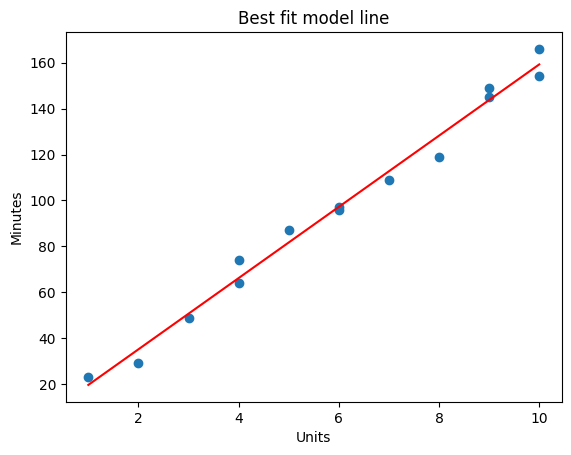

Intercept: 4.161654135338296
Coefficients: [15.50877193]


'SST:'

27768.35714285714

'SSE:'

348.84837092731806

...

27419.508771929824

'Rsq:'

0.9874371980620736

'Rsq1:'

0.9874371980620736

In [5]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline

uploaded = files.upload()
computers_filename = next(iter(uploaded))

df = pd.read_csv(io.StringIO(uploaded[computers_filename].decode('utf-8')))
display(df.head())

mean_value = df['Minutes'].mean()

plt.scatter(df['Units'],df['Minutes'],color='blue', marker='o')

plt.axhline(y=mean_value,c="r")

plt.annotate("Mean repair time",xy = (7.5,mean_value+2))
plt.xlabel("Units")
plt.ylabel("Minutes")
plt.show() # Display the first plot separately

# Assign the calculated model values as new columns to the DataFrame
df['min_model0'] = df['Minutes'].mean() # This will broadcast the mean value to all rows
df['min_model1'] = 10 + 12*df['Units']
df['min_model2'] = 6 + 18*df['Units']

fig,ax = plt.subplots() # Created a new figure and axes for the second plot

ax.scatter(x="Units",y="Minutes",data=df,label='actual repair time')

ax.plot(df['Units'],df['min_model0'],color="red",label='model0')

ax.plot(df['Units'],df['min_model1'],color="green",label='model1')

ax.plot(df['Units'],df['min_model2'],color="black",label='model2')

ax.set_ylabel("Minutes")
ax.set_xlabel("Units")
ax.set_title("Speculated Models")
ax.legend()
plt.show() # Display the second plot separately


model0_obs = pd.DataFrame({"Units":df['Units'],
              "Actual time":df['Minutes'],
              "Predicted time":df['min_model0'],
              "Error":(df['min_model0'] - df['Minutes'])})
display(model0_obs)

# Sum of squared errors
display('SSE for model0 is:',sum(model0_obs['Error']**2))

model1_obs = pd.DataFrame({"Units":df.Units,
              "Actual time":df.Minutes,
              "Predicted time":df.min_model1,
              "Error":(df.min_model1 - df.Minutes)})
display(model1_obs)
# SSE for Model1
display('SSE for model1 is:',sum(model1_obs.Error**2))


model2_obs = pd.DataFrame({"Units":df.Units,
              "Actual time":df.Minutes,
              "Predicted time":df.min_model2,
              "Error":(df.min_model2 - df.Minutes)})
display(model2_obs)
# SSE for Model2
display('SSE for model2 is:',sum(model2_obs.Error**2))

x = df.Units
y = df.Minutes
xiyi = x*y
n = len(df)
xmean = df.Units.mean()
ymean = df.Minutes.mean()
numerator = xiyi.sum() - n*xmean*ymean
denominator = (x**2).sum() - n*(xmean**2)
m = numerator/denominator
c = ymean - (m*xmean)
print('intercept : ',c,' coefficient : ',m)

min_best_fit_model = c + m*df.Units
df['min_best_fit_model'] = min_best_fit_model
display(df[["Units","Minutes","min_best_fit_model"]]) # Display this before the best fit model obs

best_fit_model_obs = pd.DataFrame({"Units":df.Units,
              "Actual time":df.Minutes,
              "Predicted time":df.min_best_fit_model,
              "Error":df.min_best_fit_model - df.Minutes})
display(best_fit_model_obs)
# Sum of Squared Errors for the best fit model
display('SSE for best fit model is:',sum(best_fit_model_obs.Error**2))

# Now, plot the best fit model line graph after the observations table
fig,ax = plt.subplots()
ax.scatter(x="Units",y="Minutes",data=df)
ax.plot(df.Units,df.min_best_fit_model,color="red")
ax.set_ylabel("Minutes")
ax.set_xlabel("Units")
ax.set_title("Best fit model line")
plt.show()

X = df[['Units']]
y=df['Minutes']
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
print("Intercept:", model.intercept_)
print("Coefficients:",model.coef_)

SST = sum((df.Minutes.mean() - df.Minutes)**2)
display('SST:',SST)
SSE = sum(best_fit_model_obs.Error**2)
display('SSE:',SSE)
SSR = SST - SSE
display('SSR:',SSR)
Rsq = SSR/SST
display('Rsq:',Rsq)
Rsq1 = model.score(df[["Units"]],y)
display('Rsq1:',Rsq1)